In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.ticker import MaxNLocator
from typing import Tuple, Dict, Any, List, Optional
from matplotlib.colors import LinearSegmentedColormap

In [5]:
dpath_cm6 = "/N/slate/kmluong/regDL-TCIP/CMIP6/level_2_data/wrf_tropical_cyclone_track_5f_14v_dataset_X.npy"
dpath_wrf = "/N/slate/kmluong/regDL-TCIP/IDEALIZED/level_2_data/wrf_idealized_track_480f_12v_dataset_X.npy"
cm6=np.load(dpath_cm6)
wrf=np.load(dpath_wrf)
print(cm6.shape, wrf.shape)
dp_cm62='/N/slate/kmluong/regDL-TCIP/CMIP6/level_2_data/wrf_tropical_cyclone_track_5f_14v_dataset_Z.npy'
cm6z=np.load(dp_cm62)
cm6latp=f"/N/u/kmluong/BigRed200/Deep-learning-intensity-projection/test_space/cm6lat.npy"
cm6lonp=f"/N/u/kmluong/BigRed200/Deep-learning-intensity-projection/test_space/cm6lon.npy"
cm6lat=np.load(cm6latp)
cm6lon=np.load(cm6lonp)


(2731, 5, 100, 100, 14) (10, 480, 100, 100, 12)


In [ ]:
def _wrap_lon_diff_2d(lon2d: np.ndarray, lon0: float) -> np.ndarray:
    """
    Minimal lon difference in degrees, wrapped to [-180, 180).
    Works whether lon grid is in [0,360) or [-180,180).
    """
    d = lon2d.astype(np.float64) - float(lon0)
    return (d + 180.0) % 360.0 - 180.0

def _clamp_start(center: int, win: int, n: int) -> int:
    """
    Start index for a length-win window, keeping in-bounds.
    """
    half = win // 2
    start = center - half
    if start < 0:
        start = 0
    max_start = n - win
    if start > max_start:
        start = max_start
    return int(start)
def truncate_cmap(cmap_name, minval=0.125, maxval=0.875, n=256):
    cmap = plt.get_cmap(cmap_name)
    new_colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list(f"trunc({cmap_name})", new_colors)
def get_100_coords_cm6(
    center_lonlat: Tuple[float, float],
    cm6lat: np.ndarray,
    cm6lon: np.ndarray,
    win_hw: Tuple[int, int] = (10, 10),
) -> Dict[str, Any]:
    """Return the coordinate window centered nearest to a supplied (lon, lat)."""
    if cm6lat.shape != cm6lon.shape:
        raise ValueError(f"cm6lat and cm6lon must have same shape. Got {cm6lat.shape} vs {cm6lon.shape}.")
    if cm6lat.ndim != 3 or cm6lat.shape[0] != 1:
        raise ValueError(f"Expected cm6lat/cm6lon shape (1,H,W). Got {cm6lat.shape}.")

    lon0, lat0 = map(float, center_lonlat)
    if not np.isfinite(lon0) or not np.isfinite(lat0):
        raise ValueError(f"Center lon/lat must be finite. Got {(lon0, lat0)}.")

    lat2d = cm6lat[0]  # (H,W)
    lon2d = cm6lon[0]  # (H,W)
    H, W = lat2d.shape

    win_h, win_w = int(win_hw[0]), int(win_hw[1])
    if win_h > H or win_w > W:
        raise ValueError(f"Window {win_h}x{win_w} larger than grid {H}x{W}.")

    # Nearest point (r0, c0)
    dlat = lat2d.astype(np.float64) - lat0
    dlon = _wrap_lon_diff_2d(lon2d, lon0)
    dist2 = dlat * dlat + dlon * dlon
    flat = int(np.argmin(dist2))
    r0, c0 = np.unravel_index(flat, dist2.shape)

    # Window slices (10x10), keep in bounds
    r_start = _clamp_start(int(r0), win_h, H)
    c_start = _clamp_start(int(c0), win_w, W)
    rs = slice(r_start, r_start + win_h)
    cs = slice(c_start, c_start + win_w)

    lat_win = lat2d[rs, cs]
    lon_win = lon2d[rs, cs]

    # (100,2) -> (lon, lat)
    coords = np.stack([lon_win.reshape(-1), lat_win.reshape(-1)], axis=1)

    return {
        "coords": coords,
        "center_rc": (int(r0), int(c0)),
        "window_slices": (rs, cs),
        "target_latlon": (lat0, lon0),
    }
def _build_regular_latlon_grid(
    H: int,
    W: int,
    center_lat: float,
    center_lon: float,
    sep_deg: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Regular lat/lon grid (degrees) centered at (center_lat, center_lon)
    with constant spacing sep_deg.

    Returns:
      lon2d, lat2d: (H,W)
    """
    r0 = (H - 1) / 2.0
    c0 = (W - 1) / 2.0
    lat_1d = center_lat + (np.arange(H, dtype=np.float64) - r0) * sep_deg
    lon_1d = center_lon + (np.arange(W, dtype=np.float64) - c0) * sep_deg
    lon2d, lat2d = np.meshgrid(lon_1d, lat_1d)
    return lon2d, lat2d


def _extent_from_lonlat(lon2d: np.ndarray, lat2d: np.ndarray) -> Tuple[float, float, float, float]:
    """imshow extent = (xmin, xmax, ymin, ymax) in degrees."""
    return (float(np.nanmin(lon2d)), float(np.nanmax(lon2d)),
            float(np.nanmin(lat2d)), float(np.nanmax(lat2d)))


def _build_cm6_lonlat_maps_from_z(
    cm6z: np.ndarray,
    cm6_id: int,
    cm6lat: np.ndarray,
    cm6lon: np.ndarray,
    win_hw: Tuple[int, int],
    frame_indices: Tuple[int, ...] = (0, 1, 2, 3),
) -> np.ndarray:
    """Build coordinate maps from the lon/lat stored for each frame in the new Z array."""
    if cm6z.ndim != 3 or cm6z.shape[2] < 2:
        raise ValueError(
            f"Expected cm6z shape [sample, frame, feature>=2], got {cm6z.shape}"
        )
    if not (0 <= cm6_id < cm6z.shape[0]):
        raise IndexError(f"cm6_id out of range for cm6z: {cm6_id} / {cm6z.shape[0]}")

    frame_idx = np.asarray(frame_indices, dtype=int)
    if frame_idx.size == 0 or frame_idx.min() < 0 or frame_idx.max() >= cm6z.shape[1]:
        raise IndexError(
            f"frame_indices={frame_indices} outside cm6z frame dimension {cm6z.shape[1]}"
        )

    centers_lonlat = np.asarray(cm6z[cm6_id, frame_idx, :2], dtype=np.float64)
    if not np.all(np.isfinite(centers_lonlat)):
        raise ValueError(f"Non-finite lon/lat in cm6z sample {cm6_id}: {centers_lonlat}")

    win_h, win_w = map(int, win_hw)
    maps = []
    for center_lon, center_lat in centers_lonlat:
        out = get_100_coords_cm6(
            center_lonlat=(center_lon, center_lat),
            cm6lat=cm6lat,
            cm6lon=cm6lon,
            win_hw=(win_h, win_w),
        )
        maps.append(out["coords"].reshape(win_h, win_w, 2))

    return np.stack(maps, axis=0)


def plot_cm6_wrf_8panels_single_cbar_geoaxis_from_cm6id(
    cm6: np.ndarray,
    wrf: np.ndarray,
    cm6z: np.ndarray,             # [sample, frame, feature], first two = lon,lat
    cm6lat: np.ndarray,           # (1, H0, W0) global CMIP6 lat grid
    cm6lon: np.ndarray,           # (1, H0, W0) global CMIP6 lon grid
    cm6_id: int,
    wrf_id: int,
    wrf_start: int = 0,

    # plotting config
    u_ch: int = 0,
    v_ch: int = 1,
    shade_ch: int = 11,
    quiver_step: int = 6,
    quiver_scale: float | None = None,
    ref_speed: float = 1.0,
    Xs=1.5, Ys=-0.08,
    spine_lw: float = 2.0,
    wspace: float = 0.02,
    hspace: float = 0.06,          # NEW: increase vertical spacing

    # axis / mapping config
    win_hw: Tuple[int, int] = (100, 100),
    # Right panels fixed axis:
    wrf_center_lat: float = 20.0498,
    wrf_center_lon: float = 0.0,
    wrf_sep_deg: float = 0.173,

    # NEW: colorbar labels (optional)
    cbar_label_left: str = "CMIP6 PSFC (hPa)",
    cbar_label_right: str = "IDEALIZED PSFC (hPa)",
    cm='cividis', pc=0.75, cxx1=0, cyy1=0, cxx2=0, cyy2=0

):
    """
    Uses the per-frame lon/lat stored directly in the new cm6z array.

    Other plotting behavior:
      1) X-axis ticks/labels are shown ONLY on the TOP row of each column (top axis).
         Bottom axes are hidden to reduce clutter.
      2) Increase hspace (vertical spacing).
      3) TWO colorbars: one for the left column (CM6) and one for the right column (WRF).
         (So: each 4-panel column has its own cbar.)
    """
    # ----------------------------
    # Checks
    # ----------------------------
    #cm6[:,:,:,:,shade_ch]=cm6[:,:,:,:,shade_ch]/100
    #wrf[:,:,:,:,shade_ch]=wrf[:,:,:,:,shade_ch]/100
    cm = truncate_cmap("RdYlBu_r", (1-pc)/2, 1-(1-pc)/2)
    if cm6.ndim != 5 or wrf.ndim != 5:
        raise ValueError(f"Need cm6 5D and wrf 5D. Got {cm6.shape} and {wrf.shape}")

    n_cm6, t_cm6, H, W, Cc = cm6.shape
    n_wrf, t_wrf, H2, W2, Cw = wrf.shape

    if (H, W) != (H2, W2):
        raise ValueError(f"Spatial mismatch: CM6 {(H, W)} vs WRF {(H2, W2)}")
    if t_cm6 < 4:
        raise ValueError(f"CM6 time dim must be >=4. Got {t_cm6}")
    if t_wrf < 4:
        raise ValueError(f"WRF time dim must be >=4. Got {t_wrf}")

    if not (0 <= cm6_id < n_cm6):
        raise IndexError(f"cm6_id out of range: {cm6_id} / {n_cm6}")
    if not (0 <= wrf_id < n_wrf):
        raise IndexError(f"wrf_id out of range: {wrf_id} / {n_wrf}")

    if cm6z.ndim != 3 or cm6z.shape[2] < 2:
        raise ValueError(
            f"Expected cm6z shape [sample, frame, feature>=2], got {cm6z.shape}"
        )
    if cm6z.shape[0] != n_cm6:
        raise ValueError(f"CM6/Z sample mismatch: {n_cm6} vs {cm6z.shape[0]}")
    if cm6z.shape[1] < 4:
        raise ValueError(f"cm6z must contain at least 4 frames, got {cm6z.shape[1]}")

    if wrf_start < 0 or (wrf_start + 3) >= t_wrf:
        raise IndexError(f"Need wrf time indices [{wrf_start}..{wrf_start+3}] within [0,{t_wrf-1}]")

    if max(u_ch, v_ch, shade_ch) >= Cc:
        raise ValueError(f"CM6 channel index out of range. C={Cc}")
    if max(u_ch, v_ch, shade_ch) >= Cw:
        raise ValueError(f"WRF channel index out of range. C={Cw}")
    if ref_speed <= 0:
        raise ValueError("ref_speed must be > 0")

    win_h, win_w = int(win_hw[0]), int(win_hw[1])
    if (win_h, win_w) != (H, W):
        raise ValueError(f"win_hw {win_hw} must match data spatial {(H, W)} for correct extents.")

    # ----------------------------
    # Build maps from the four center coordinates already stored in cm6z.
    # ----------------------------
    cm6_lonlat_4 = _build_cm6_lonlat_maps_from_z(
        cm6z=cm6z,
        cm6_id=cm6_id,
        cm6lat=cm6lat,
        cm6lon=cm6lon,
        win_hw=win_hw,
        frame_indices=(0, 1, 2, 3),
    )  # (4,H,W,2), last dimension is (lon,lat)

    # ----------------------------
    # WRF fixed geo grid
    # ----------------------------
    lon2d_wrf, lat2d_wrf = _build_regular_latlon_grid(
        H=H, W=W,
        center_lat=wrf_center_lat,
        center_lon=wrf_center_lon,
        sep_deg=wrf_sep_deg,
    )
    extent_wrf = _extent_from_lonlat(lon2d_wrf, lat2d_wrf)
    lonQ_wrf = lon2d_wrf[::quiver_step, ::quiver_step]
    latQ_wrf = lat2d_wrf[::quiver_step, ::quiver_step]

    # ----------------------------
    # Shared shading scale per column (NEW: 2 cbars)
    # ----------------------------
    cm6_shades = [cm6[cm6_id, r, :, :, shade_ch] for r in range(4)]
    wrf_shades = [wrf[wrf_id, wrf_start + r, :, :, shade_ch] for r in range(4)]

    vmin_L = float(min(s.min() for s in cm6_shades))
    vmax_L = float(max(s.max() for s in cm6_shades))
    vmin_R = float(min(s.min() for s in wrf_shades))
    vmax_R = float(max(s.max() for s in wrf_shades))

    # ----------------------------
    # Helper: style axes
    # ----------------------------
    def _fmt_lon_labels(vals: np.ndarray) -> list[str]:
        """Format longitudes with E/W suffix (degrees)."""
        out = []
        for v in vals:
            x = float(v)
            # wrap to [-180,180)
            xw = (x + 180.0) % 360.0 - 180.0
            if abs(xw) < 1e-10:
                out.append("0°")
            elif xw > 0:
                out.append(f"{abs(xw):g}°E")
            else:
                out.append(f"{abs(xw):g}°W")
        return out

    def _fmt_lat_labels(vals: np.ndarray) -> list[str]:
        """Format latitudes with N/S suffix (degrees)."""
        out = []
        for v in vals:
            y = float(v)
            if abs(y) < 1e-10:
                out.append("0°")
            elif y > 0:
                out.append(f"{abs(y):g}°N")
            else:
                out.append(f"{abs(y):g}°S")
        return out


    def style_panel(
        ax,
        t_label: str,
        lw: float,
        show_top: bool,
        show_bottom: bool,
        nticks: int = 4,
        show_y: bool = True,      # NEW
        y_right: bool = False,    # NEW
    ):
        # border
        for sp in ax.spines.values():
            sp.set_linewidth(lw)

        # time tag
        ax.set_title("")
        ax.text(
            0.98, 0.98, t_label,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=11,
            bbox=dict(facecolor="white", edgecolor="black",
                    boxstyle="round,pad=0.25", linewidth=1.2),
            zorder=10
        )

        ax.set_xlabel("")
        ax.set_ylabel("")

        # --- limit ticks ---
        ax.xaxis.set_major_locator(MaxNLocator(nbins=nticks))
        if show_y:
            ax.yaxis.set_major_locator(MaxNLocator(nbins=nticks))

        # ----- Y ticks control (NEW) -----
        if not show_y:
            ax.set_yticks([])
            ax.set_yticklabels([])
            ax.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
        else:
            # choose side
            if y_right:
                ax.yaxis.tick_right()
                ax.tick_params(axis="y", right=True, left=False, labelright=True, labelleft=False, direction="out")
            else:
                ax.yaxis.tick_left()
                ax.tick_params(axis="y", left=True, right=False, labelleft=True, labelright=False, direction="out")

            # format lat labels (only when showing y)
            yt = ax.get_yticks()
            ax.set_yticklabels(_fmt_lat_labels(yt))

        # ----- X ticks: bottom + top -----
        ax.tick_params(axis="x", which="both", bottom=True, top=False,
                    labelbottom=show_bottom, labeltop=False, direction="out")
        if show_bottom:
            xt = ax.get_xticks()
            ax.set_xticklabels(_fmt_lon_labels(xt))
        else:
            ax.set_xticklabels([])

        # Top axis
        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xlabel("")
        ax_top.set_ylabel("")
        ax_top.patch.set_visible(False)
        for sp in ax_top.spines.values():
            sp.set_linewidth(lw)

        ax_top.xaxis.set_major_locator(MaxNLocator(nbins=nticks))
        ax_top.tick_params(axis="x", which="both", top=True, bottom=False,
                        labeltop=show_top, labelbottom=False, direction="out")
        if show_top:
            xt2 = ax_top.get_xticks()
            ax_top.set_xticklabels(_fmt_lon_labels(xt2))
        else:
            ax_top.set_xticklabels([])

        return ax_top

    # ----------------------------
    # Figure + panels (UPDATED: 2 rows x 4 cols)
    #   Row 0: CMIP6 (t0..t3)
    #   Row 1: WRF/Idealized (t0..t3)
    # ----------------------------
    fig, axes = plt.subplots(2, 4, figsize=(15.5, 8))
    for ax in axes.flat:
        ax.set_box_aspect(1)
    plt.subplots_adjust(right=0.90, hspace=hspace, wspace=wspace)

    im_ref_cm6 = None
    im_ref_wrf = None
    q_ref = None

    for i in range(4):
        # i = 0..3 corresponds to time index r in your old code
        r = i
        show_y = (i == 0) or (i == 3)
        y_right = (i == 3)
        
        # ===== Top row (CM6)
        axC = axes[0, i]
        frameC = cm6[cm6_id, r]  # (H,W,C)

        shadeC = frameC[:, :, shade_ch]
        uC = frameC[:, :, u_ch]
        vC = frameC[:, :, v_ch]

        lon2d_cm6 = cm6_lonlat_4[r, :, :, 0]
        lat2d_cm6 = cm6_lonlat_4[r, :, :, 1]
        extent_cm6 = _extent_from_lonlat(lon2d_cm6, lat2d_cm6)

        lonQ_cm6 = lon2d_cm6[::quiver_step, ::quiver_step]
        latQ_cm6 = lat2d_cm6[::quiver_step, ::quiver_step]
        uQ_cm6 = uC[::quiver_step, ::quiver_step]
        vQ_cm6 = vC[::quiver_step, ::quiver_step]

        im_ref_cm6 = axC.imshow(
            shadeC,
            origin="lower",
            vmin=vmin_L, vmax=vmax_L,
            extent=extent_cm6,
            aspect="auto",
            cmap=cm
        )
        qC = axC.quiver(
            lonQ_cm6, latQ_cm6,
            uQ_cm6, vQ_cm6,
            angles="xy",
            scale_units="xy",
            scale=quiver_scale,
        )
        if q_ref is None:
            q_ref = qC

        # Top row: show top labels; bottom labels off
        style_panel(
            axC,
            t_label=f"t={r*6:02d}:00",
            lw=spine_lw,
            show_top=True,
            show_bottom=False,
            show_y=show_y,
            y_right=y_right
        )
        if i == 0:
            axC.text(
                0.98, 0.02, "         \n         ",                 
                transform=axC.transAxes,
                ha="right", va="bottom",
                fontsize=11,
                bbox=dict(
                    facecolor="white",
                    edgecolor="black",
                    boxstyle="round,pad=0.35",
                    linewidth=1.2
                ),
                zorder=20
            )
        # ===== Bottom row (WRF/Idealized)
        axW = axes[1, i]
        frameW = wrf[wrf_id, wrf_start + r]

        shadeW = frameW[:, :, shade_ch]
        uW = frameW[:, :, u_ch]
        vW = frameW[:, :, v_ch]

        uQ_wrf = uW[::quiver_step, ::quiver_step]
        vQ_wrf = vW[::quiver_step, ::quiver_step]

        im_ref_wrf = axW.imshow(
            shadeW,
            origin="lower",
            vmin=vmin_R, vmax=vmax_R,
            extent=extent_wrf,
            aspect="auto",
            cmap=cm
        )
        axW.quiver(
            lonQ_wrf, latQ_wrf,
            uQ_wrf, vQ_wrf,
            angles="xy",
            scale_units="xy",
            scale=quiver_scale,
        )

        # Bottom row: show bottom labels; top labels off
        style_panel(
            axW,
            t_label=f"t={r//2:02d}:{(r%2)*30:02d}",
            lw=spine_lw,
            show_top=False,
            show_bottom=True,
            show_y=show_y,
            y_right=y_right
        )

    # ----------------------------
    # TWO colorbars (UPDATED for 2x4): one per row
    # ----------------------------
    # Colorbar for CMIP6 row
    cbar_ax_C = fig.add_axes([cxx1, cyy1, 0.018, 0.34])
    cbar_C = fig.colorbar(im_ref_cm6, cax=cbar_ax_C)
    cbar_C.set_label(cbar_label_left)

    # Colorbar for WRF/Idealized row
    cbar_ax_W = fig.add_axes([cxx2, cyy2, 0.018, 0.34])
    cbar_W = fig.colorbar(im_ref_wrf, cax=cbar_ax_W)
    cbar_W.set_label(cbar_label_right)

    # ----------------------------
    # One reference arrow (keep it near top colorbar)
    # ----------------------------
    cbar_ax_C.set_clip_on(False)
    cbar_ax_C.quiverkey(
        q_ref,
        X=Xs, Y=Ys,
        U=ref_speed,
        label=f"{ref_speed:g} m/s",
        labelpos="S",
        coordinates="axes"
    )

    # ----------------------------
    # Row titles (UPDATED)
    # ----------------------------
    # --- Row titles centered across the whole row (replace axes[0,0].set_title / axes[1,0].set_title) ---
    # compute the horizontal center of the 4-panel grid (exclude colorbar area)
    x_center = 0.5 * (axes[0, 0].get_position().x0 + axes[0, 3].get_position().x1)

    # y just above top row and between rows
    y_top = axes[0, 0].get_position().y1 + 0.045
    y_mid = axes[1, 0].get_position().y1 + 0.02

    fig.text(x_center, y_top, "CMIP6", ha="center", va="bottom",
            fontsize=14, fontweight="bold")
    fig.text(x_center, y_mid, "Idealized", ha="center", va="bottom",
            fontsize=14, fontweight="bold")

    return fig

In [ ]:
#fig = plot_cm6_wrf_8panels_single_cbar(cm6, wrf, cm6_id=998, wrf_id=3, ref_speed=20.0, quiver_scale=5, Xs=2.44, Ys=-2.75, wrf_start=420)
#fig.savefig('8panels.png', dpi=440)
cm61=np.copy(cm6)
wrf1=np.copy(wrf)
cm61[:,:,:,:,11]=cm6[:,:,:,:,11]/100
wrf1[:,:,:,:,11]=wrf[:,:,:,:,11]/100
fig = plot_cm6_wrf_8panels_single_cbar_geoaxis_from_cm6id(
    cm6=cm61,
    wrf=wrf1,
    cm6z=cm6z,           # (sample, frame, 6), columns 0/1 are lon/lat
    cm6lat=cm6lat,      # (1,719,899) global
    cm6lon=cm6lon,      # (1,719,899) global
    cm6_id=998,
    wrf_id=3,
    wrf_start=420,
    win_hw=(100,100),
    wrf_center_lat=20.0498,
    wrf_center_lon=0.0,
    wrf_sep_deg=0.173,
    ref_speed=20.0, quiver_scale=42, Xs=0.9, Ys=0.11, hspace=0.15, wspace=0.13, cm='RdYlBu_r', pc=0.6, cyy1=0.54, cyy2=0.12, cxx1=0.94, cxx2=0.94)
#[0.92, 0.52, 0.018, 0.34]
#[0.92, 0.08, 0.018, 0.34]

In [ ]:
fig.savefig("8panels.png", dpi=440, bbox_inches="tight")

In [ ]:
plt.plot(cm6z[:, :, 1])


d1 shape: (273, 5, 100, 100, 12)
d2 shape: (2731, 5, 100, 100, 12)

d1[150] vs d2[1902]
exact same: False
allclose: False
max abs diff: 20.890137

d1[150] vs d2[1903]
exact same: True
allclose: True
max abs diff: 0.0

d1[150] vs d2[1904]
exact same: False
allclose: False
max abs diff: 19.272297


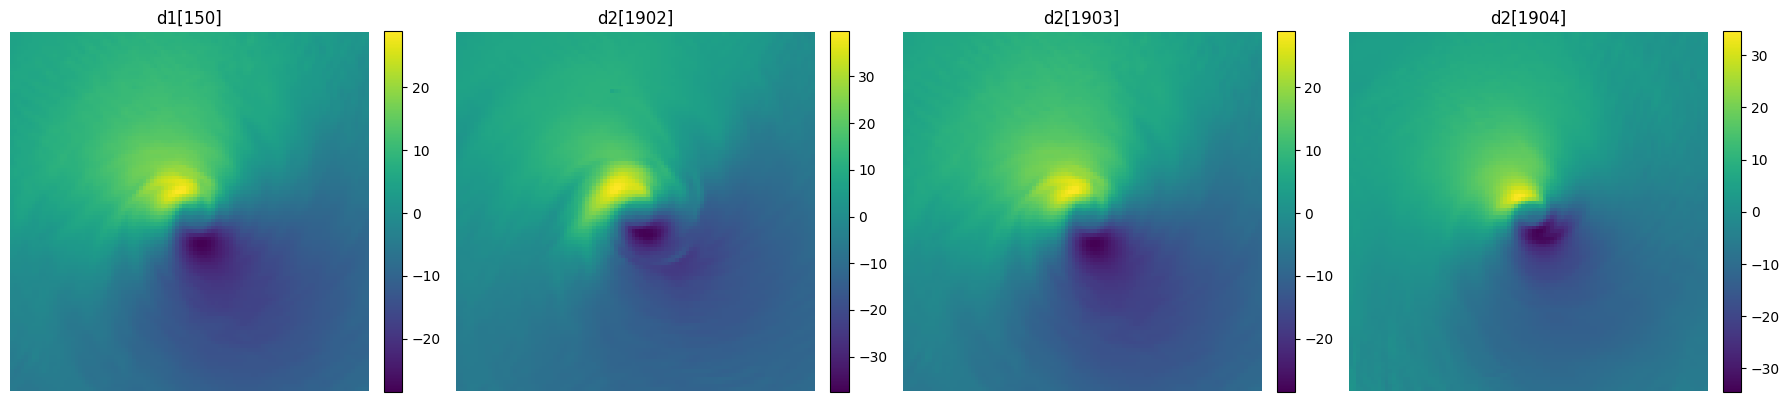

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

d1_path = "/N/slate/kmluong/regDL-TCIP/CMIP6/tmp/test.npy"
d2_path = "/N/slate/kmluong/regDL-TCIP/CMIP6/level_2_data/wrf_tropical_cyclone_track_5f_12v_dataset_X.npy"

# Load as mmap to avoid loading whole file into RAM
d1 = np.load(d1_path, mmap_mode="r")
d2 = np.load(d2_path, mmap_mode="r")

print("d1 shape:", d1.shape)
print("d2 shape:", d2.shape)

# shape: sample, frame, h, w, c
x1 = d1[150, 0, :, :, 0]
x2_list = [d2[i, 0, :, :, 0] for i in [1902, 1903, 1904]]

# Compare d1 sample 150 with d2 samples 1902-1904
for idx, x2 in zip([1902, 1903, 1904], x2_list):
    same_exact = np.array_equal(x1, x2)
    same_close = np.allclose(x1, x2, equal_nan=True)
    max_abs_diff = np.nanmax(np.abs(x1 - x2))

    print(f"\nd1[150] vs d2[{idx}]")
    print("exact same:", same_exact)
    print("allclose:", same_close)
    print("max abs diff:", max_abs_diff)

# Plot d1[150] and d2[1902:1904], frame 0, channel 0
samples = [("d1[150]", x1)] + [(f"d2[{idx}]", x2) for idx, x2 in zip([1902, 1903, 1904], x2_list)]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (title, img) in zip(axes, samples):
    im = ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
diffs = []

for idx in [1902, 1903, 1904]:
    x2 = d2[idx, 0, :, :, 0]
    diff = np.nanmax(np.abs(x1 - x2))
    diffs.append((idx, diff))

best_idx, best_diff = min(diffs, key=lambda x: x[1])
print("Best match:", best_idx, "max abs diff:", best_diff)

Best match: 1903 max abs diff: 0.0


In [ ]:
d3_path = "/N/slate/kmluong/regDL-TCIP/CMIP6/level_2_data/wrf_tropical_cyclone_track_5f_12v_dataset_Z.npy"

In [ ]:
z=np.load("cm6lon.npy")
z.shape

(1, 719, 899)

In [ ]:
lo1= 135.22
la1=16.23
lo2=131.71        
la2=19.29
lod=(lo2-lo1)/3
lad=(la2-la1)/3
lo = [lo1+i*lod for i in(0,1,2,3)]
la = [la1+i*lad for i in(0,1,2,3)]
print(lo,la)

[135.22, 134.05, 132.88, 131.71] [16.23, 17.25, 18.27, 19.29]


In [ ]:
import numpy as np

lat = np.load("cm6lat.npy")[0]  # (719, 899)
lon = np.load("cm6lon.npy")[0]  # (719, 899)

lo_arr = np.asarray(lo)
la_arr = np.asarray(la)

for k, (lo_k, la_k) in enumerate(zip(lo_arr, la_arr)):
    lo_use = lo_k

    # Convert -180..180 -> 0..360 nếu cần
    if lon.max() > 180 and lo_use < 0:
        lo_use = lo_use % 360

    dist2 = (lat - la_k) ** 2 + (lon - lo_use) ** 2
    iy, ix = np.unravel_index(np.nanargmin(dist2), dist2.shape)

    half = 50
    H, W = lat.shape

    y0 = max(0, min(iy - half, H - 100))
    x0 = max(0, min(ix - half, W - 100))
    y1 = y0 + 100
    x1 = x0 + 100

    lat_crop = lat[y0:y1, x0:x1]
    lon_crop = lon[y0:y1, x0:x1]

    print(f"\nTarget {k}")
    print("target lon/lat:", lo_k, la_k)
    print("nearest iy/ix:", iy, ix)
    print("nearest lon/lat:", lon[iy, ix], lat[iy, ix])
    print("crop y:", y0, y1)
    print("crop x:", x0, x1)
    print("target position inside crop:", iy - y0, ix - x0)
    print("crop shape:", lat_crop.shape, lon_crop.shape)


Target 0
target lon/lat: 135.22 16.23
nearest iy/ix: 136 377
nearest lon/lat: 135.2178 16.230347
crop y: 86 186
crop x: 327 427
target position inside crop: 50 50
crop shape: (100, 100) (100, 100)

Target 1
target lon/lat: 134.05 17.25
nearest iy/ix: 147 365
nearest lon/lat: 134.01494 17.286125
crop y: 97 197
crop x: 315 415
target position inside crop: 50 50
crop shape: (100, 100) (100, 100)

Target 2
target lon/lat: 132.88 18.27
nearest iy/ix: 157 354
nearest lon/lat: 132.91232 18.240707
crop y: 107 207
crop x: 304 404
target position inside crop: 50 50
crop shape: (100, 100) (100, 100)

Target 3
target lon/lat: 131.71 19.29
nearest iy/ix: 168 342
nearest lon/lat: 131.70946 19.284721
crop y: 118 218
crop x: 292 392
target position inside crop: 50 50
crop shape: (100, 100) (100, 100)
